# Exploratory Data Analysis

## 1. Objective

This analysis examines the relationship between drone-derived bamboo
structural parameters and clump-level above-ground biomass.

The objectives are to:

- assess the quality and distribution of the modelling dataset;
- examine relationships between biomass and canopy parameters;
- identify potential redundant predictors;
- investigate unusual observations;
- inform the selection of variables and model forms for biomass modelling.
  

### Author: Elkana Kipruto

In [60]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import pearsonr, spearmanr
from libpysal.weights import KNN
from esda.moran import Moran
import os

## 2. Dataset

The analysis uses dataset version DV-004.

The response variable is:

- `total_agb`: clump-level above-ground biomass (kg)

The dataset contains drone-derived canopy parameters and breast-height
structural parameters.

The dataset was corrected for the GB-03 field-parameter assignment issue
identified during model development.

In [61]:
inter_dir = '../../02_INTERMEDIATE'
merged_filepath = f'{inter_dir}/merged_acre_ecoplanet_parameters.gpkg'
if os.path.exists(merged_filepath):
    gdf = gpd.read_file(merged_filepath)
else:
    print('Invalid source path')

## 3. Data Quality Checks

Before analysing relationships, the dataset was checked for:

- missing values;
- duplicated records;
- physically implausible values;
- inconsistent units;
- duplicate clump identifiers;
- unexpected values in key structural parameters.

In [62]:
gdf.head()

,psp,year,date_of_collection,clump_id,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,...,val_canopy_diameter,breast_height_points,breast_height_valid_points,breast_height_filtered_points,breast_height_cleaning_distance,breast_height_area,breast_height_perimeter_m,breast_height_diameter,bh_outside_area_m2,geometry
0,1a-APM-01,2025,4/24/2025,CLUMP #1,11,34.65,2.78,1.86,0.36,1.85,...,NaN,3028.0,36518.0,1341.0,0.15,26.44,19.64,5.80,6.43,POINT (798561.321 9777838.896)
1,1a-APM-01,2026,4/2/2026,CLUMP #1,31,144.28,3.59,2.35,0.66,2.45,...,NaN,3739.0,46698.0,1380.0,0.16,36.30,22.56,6.80,5.70,POINT (798561.353 9777838.812)
2,1a-APM-01,2025,4/24/2025,CLUMP #2,14,16.47,2.16,1.06,0.39,0.93,...,NaN,1002.0,5810.0,1002.0,0.12,4.09,7.66,2.28,1.13,POINT (798564.115 9777833.559)
3,1a-APM-01,2026,4/2/2026,CLUMP #2,58,172.09,3.03,1.81,0.23,1.81,...,NaN,3028.0,36518.0,1341.0,0.15,26.44,19.64,5.80,6.43,POINT (798564.052 9777833.557)
4,1a-APM-01,2025,4/24/2025,CLUMP #3,0,0.00,0.00,0.00,0.00,0.00,...,NaN,1742.0,13030.0,1708.0,0.15,9.54,16.41,3.48,2.22,POINT (798566.848 9777828.454)


In [63]:
gdf.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'breast_height_points', 'breast_height_valid_points',
       'breast_height_filtered_points', 'breast_height_cleaning_distance',
       'breast_height_area', 'breast_height_perimeter_m',
       'breast_height_diameter', 'bh_outside_area_m2', 'geometry'],
      dtype='str')

In [64]:
gdf.dtypes

psp                                     str
year                                  int64
date_of_collection                      str
clump_id                                str
total_culms                           int64
total_agb                           float64
max_culm_diameter_cm                float64
avg_culm_diameter_cm                float64
min_culm_diameter_cm                float64
median_culm_diameter_cm             float64
max_culm_agb                        float64
avg_culm_agb                        float64
min_culm_agb                        float64
median_culm_agb                     float64
hmin                                float64
hmax                                float64
hmean                               float64
hstd                                float64
hmedian                             float64
total_points                          int64
canopy_volume_m3                    float64
gap_fraction                        float64
canopy_area                     

#### Ensuring the datatypes and decimal places are consistent across the dataset

In [65]:
#all the integer columns
int_cols = ["year", "total_culms", "total_points"]

# bamboo parameters that should be in decimal format
float_cols = [
    "total_agb",
    "max_culm_diameter_cm",
    "avg_culm_diameter_cm",
    "min_culm_diameter_cm",
    "median_culm_diameter_cm",
    "max_culm_agb",
    "avg_culm_agb",
    "min_culm_agb",
    "median_culm_agb",
    "hmin",
    "hmax",
    "hmean",
    "hstd",
    "hmedian",
    "canopy_volume_m3",
    "gap_fraction",
    "canopy_area",
    "val_height",
    "val_canopy_diameter",
    'breast_height_points', 'breast_height_valid_points',
    'breast_height_filtered_points', 'breast_height_cleaning_distance',
    'breast_height_area', 'breast_height_perimeter_m',
    'breast_height_diameter', 'bh_outside_area_m2'
]

# clean and convert Integer columns
for col in int_cols:
    if col in gdf.columns:
        # pd.to_numeric turns invalid strings/spaces into NaN, fillna(0) prevents crashing
        gdf[col] = pd.to_numeric(gdf[col], errors="coerce").fillna(0).astype("int64")

# clean, convert, and round Float columns to strictly 2 decimal places
for col in float_cols:
    if col in gdf.columns:
        # Convert text to actual decimals
        gdf[col] = pd.to_numeric(gdf[col], errors="coerce")
        # Round strictly to 2 decimal places
        gdf[col] = gdf[col].round(2)

print("GeoPackage successfully cleaned and types corrected!")

GeoPackage successfully cleaned and types corrected!


In [66]:
gdf.shape

(217, 34)

In [67]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   psp                              217 non-null    str     
 1   year                             217 non-null    int64   
 2   date_of_collection               217 non-null    str     
 3   clump_id                         217 non-null    str     
 4   total_culms                      217 non-null    int64   
 5   total_agb                        217 non-null    float64 
 6   max_culm_diameter_cm             217 non-null    float64 
 7   avg_culm_diameter_cm             217 non-null    float64 
 8   min_culm_diameter_cm             217 non-null    float64 
 9   median_culm_diameter_cm          217 non-null    float64 
 10  max_culm_agb                     217 non-null    float64 
 11  avg_culm_agb                     217 non-null    float64 
 12  

In [68]:
gdf.describe()

,year,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,max_culm_agb,avg_culm_agb,min_culm_agb,...,val_height,val_canopy_diameter,breast_height_points,breast_height_valid_points,breast_height_filtered_points,breast_height_cleaning_distance,breast_height_area,breast_height_perimeter_m,breast_height_diameter,bh_outside_area_m2
count,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,...,52.000000,40.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000
mean,2025.534562,21.995392,79.650783,2.151751,1.296267,0.479309,1.288249,5.075899,2.208065,0.357558,...,5.632692,5.690000,2160.551515,26127.369697,1335.630303,0.107697,13.608667,13.377939,3.840545,9.905576
std,0.499957,21.031832,99.457292,1.512861,0.908540,0.383688,0.928201,4.670561,1.986756,0.438308,...,1.604983,1.274363,1387.569486,16294.227291,817.836186,0.030013,9.735969,5.590788,1.610677,9.088953
min,2025.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,3.000000,153.000000,986.000000,153.000000,0.070000,0.520000,2.830000,0.810000,0.130000
25%,2025.000000,3.000000,0.850000,0.690000,0.450000,0.240000,0.390000,0.480000,0.240000,0.070000,...,4.675000,4.600000,1149.000000,12408.000000,765.000000,0.090000,5.580000,9.420000,2.670000,2.930000
50%,2026.000000,15.000000,34.970000,2.480000,1.480000,0.410000,1.470000,4.780000,2.070000,0.190000,...,5.800000,6.000000,1924.000000,24537.000000,1180.000000,0.090000,13.040000,13.880000,4.070000,8.610000
75%,2026.000000,38.000000,141.150000,3.320000,2.000000,0.690000,2.010000,8.100000,3.470000,0.480000,...,6.200000,6.700000,2898.000000,37785.000000,1686.000000,0.120000,20.670000,17.280000,5.130000,13.120000
max,2026.000000,82.000000,362.770000,6.520000,3.190000,1.650000,3.330000,27.400000,7.880000,2.200000,...,8.400000,7.400000,6763.000000,66516.000000,4050.000000,0.180000,47.630000,28.520000,7.790000,51.350000


<Axes: >

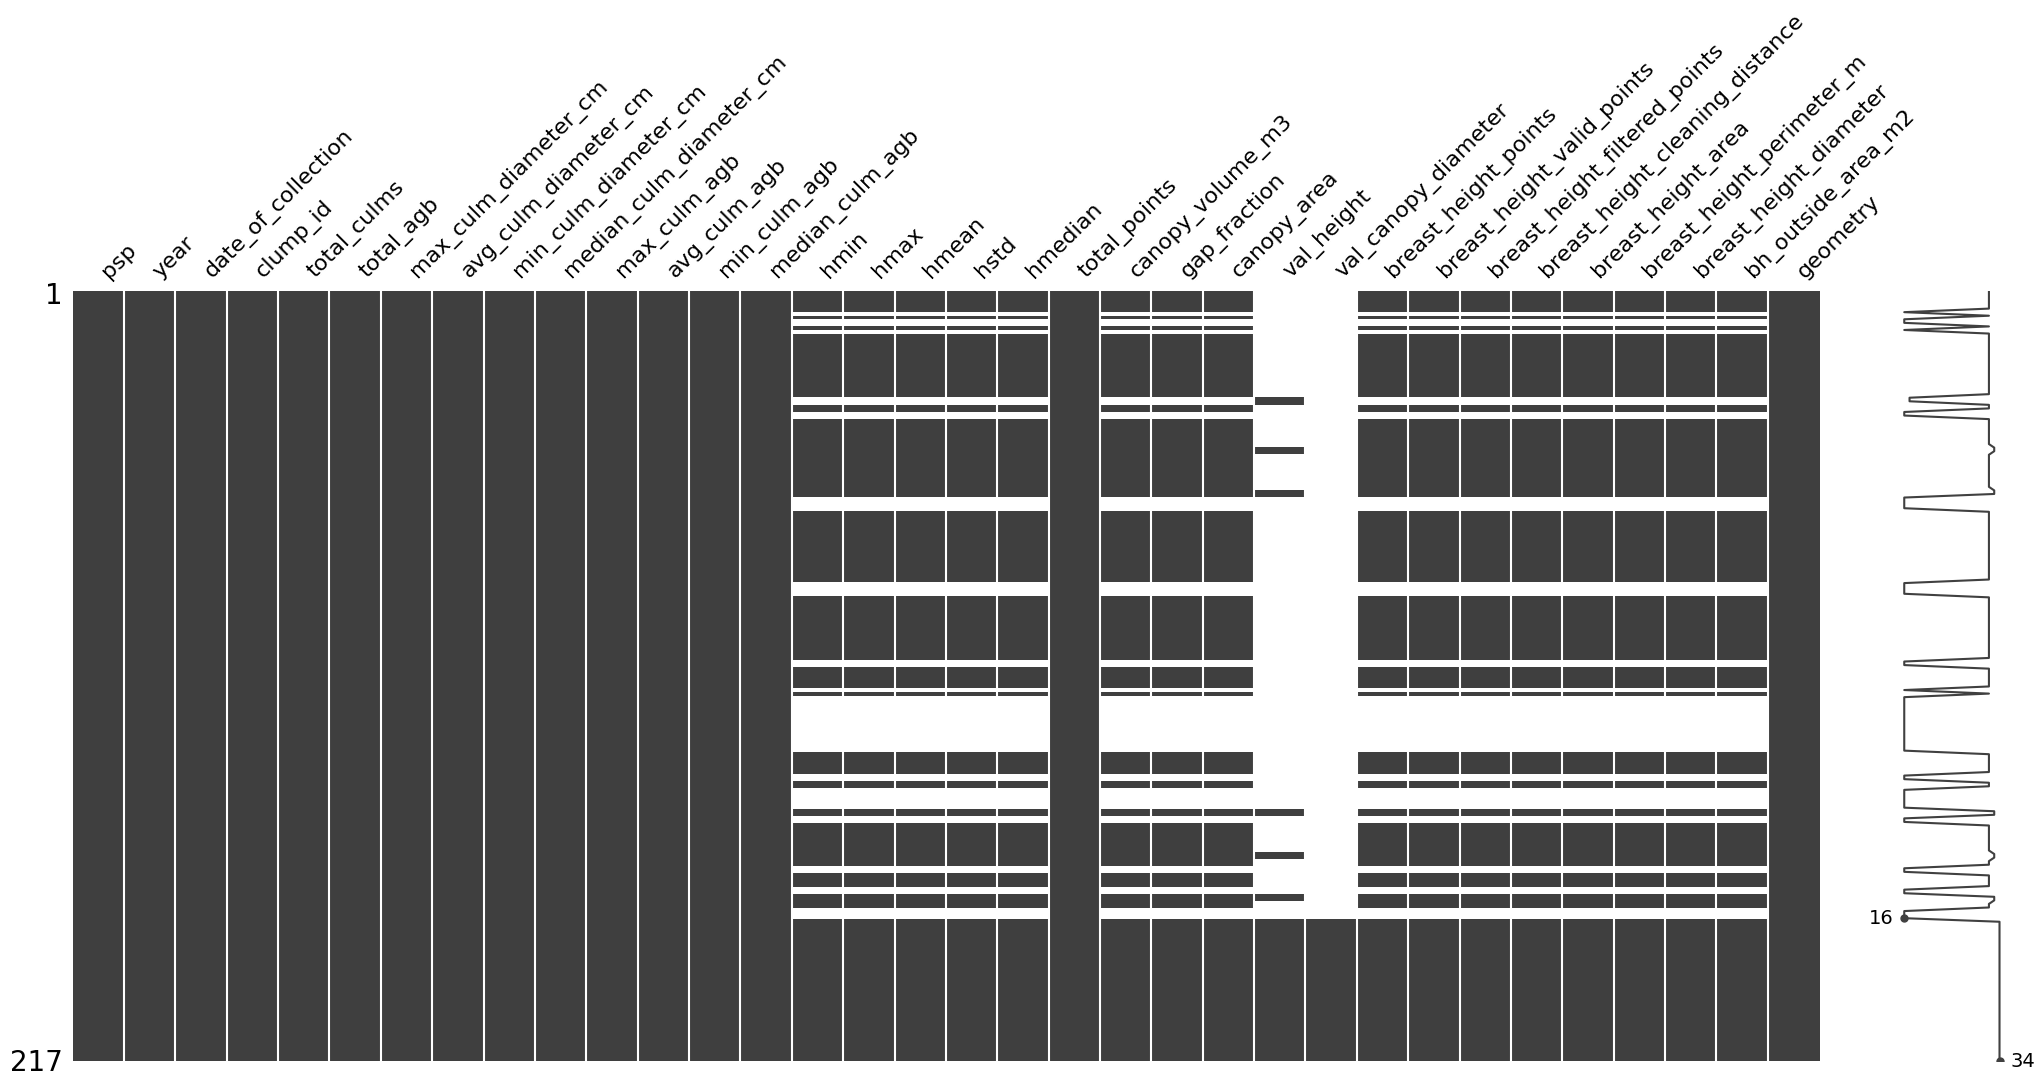

In [69]:
msno.matrix(gdf)

In [70]:
gdf.duplicated().sum()

np.int64(0)

### Check for impossible values

In [71]:
numeric_cols = gdf.select_dtypes(include='number').columns

In [72]:
for col in numeric_cols:
    print(col, gdf[gdf[col] < 0].shape)

year (0, 34)
total_culms (0, 34)
total_agb (0, 34)
max_culm_diameter_cm (0, 34)
avg_culm_diameter_cm (0, 34)
min_culm_diameter_cm (0, 34)
median_culm_diameter_cm (0, 34)
max_culm_agb (0, 34)
avg_culm_agb (0, 34)
min_culm_agb (0, 34)
median_culm_agb (0, 34)
hmin (0, 34)
hmax (0, 34)
hmean (0, 34)
hstd (0, 34)
hmedian (0, 34)
total_points (0, 34)
canopy_volume_m3 (0, 34)
gap_fraction (0, 34)
canopy_area (0, 34)
val_height (0, 34)
val_canopy_diameter (0, 34)
breast_height_points (0, 34)
breast_height_valid_points (0, 34)
breast_height_filtered_points (0, 34)
breast_height_cleaning_distance (0, 34)
breast_height_area (0, 34)
breast_height_perimeter_m (0, 34)
breast_height_diameter (0, 34)
bh_outside_area_m2 (0, 34)


#### Is 2025 data meaningful to the analysis?

In [73]:
gdf.groupby("year")["total_agb"].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2025,101.0,36.589901,53.096699,0.0,0.00,9.750,49.3000,218.39
2026,116.0,117.143448,114.373655,0.0,6.36,91.595,200.0825,362.77


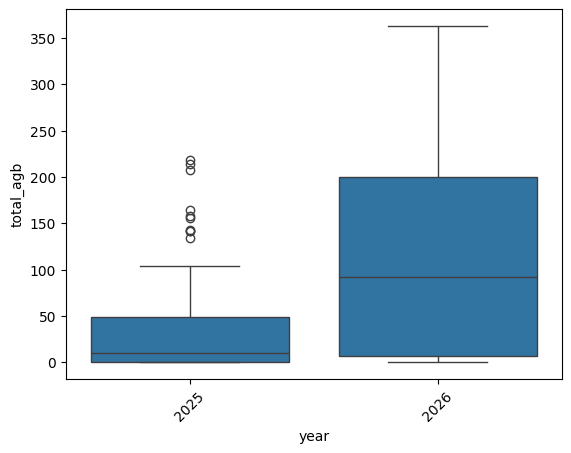

In [74]:
sns.boxplot(
    data=gdf,
    x="year",
    y="total_agb"
)

plt.xticks(rotation=45)
plt.show()

### Findings:
* **The dataset has no impossible values**
* **The datatypes and decimal places are now consistent across the dataset**
* **The dataset has no duplicates**
* **2025 data differs very much with 2026:** The changes in the clumps btn 2025 and 2026 are massive and given they share the same drone metrics, this would confuse the model and so should drop 2025.
* **Note:** For PSP GB 05, there is need to drop the march 2026 dataset as well since it has a more recent June observation, to avoid modelling with 2 different records

## 4. Variable Distributions

The distributions of biomass and the main structural predictors were
examined to identify skewness, extreme observations and differences in
scale.

In [75]:
gdf = gdf[gdf['year'] == 2026]
target_plot = '1a-GB-05'
target_date = '3/13/2026'
# filter out the specific rows using boolean indexing
gdf = gdf[~((gdf['psp'] == target_plot) & (gdf['date_of_collection'] == target_date))]
gdf = gdf[gdf['total_agb'] != 0]

In [76]:
gdf['total_agb'].describe()

count     87.000000
mean     127.818391
std      112.154785
min        0.100000
25%       22.370000
50%      115.930000
75%      208.050000
max      362.770000
Name: total_agb, dtype: float64

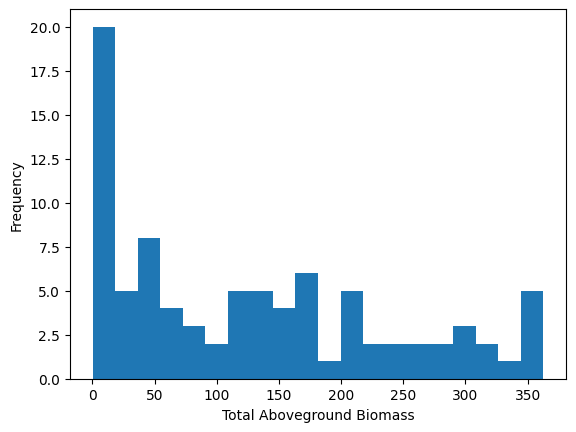

In [77]:
plt.hist(gdf['total_agb'], bins=20)
plt.xlabel('Total Aboveground Biomass')
plt.ylabel('Frequency')
plt.show()

In [78]:
gdf['total_agb'].skew()

np.float64(0.5894392875207002)

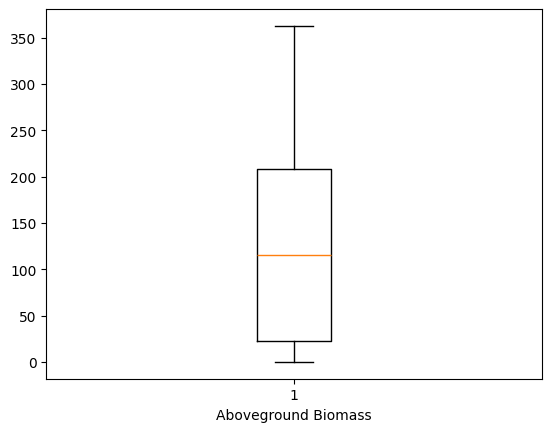

In [79]:
plt.boxplot(gdf['total_agb'])
plt.xlabel('Aboveground Biomass')
plt.show()

### Findings:
* **There is huge variation in biomass values evident from the high standard deviation**
* **The biomass values are approximately symetric with a small skew to the left**
* **There seems to be some very high biomass plants and so could be outliers or exceptional plants that should either be retained or dropped**

## 5. Relationship Between Biomass and Structural Parameters

The relationship between `total_agb` and the main canopy parameters was
examined using scatter plots and correlation statistics.

In [80]:
gdf.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'breast_height_points', 'breast_height_valid_points',
       'breast_height_filtered_points', 'breast_height_cleaning_distance',
       'breast_height_area', 'breast_height_perimeter_m',
       'breast_height_diameter', 'bh_outside_area_m2', 'geometry'],
      dtype='str')

In [81]:
gdf['adjusted_volume'] = gdf['canopy_volume_m3'] * gdf['gap_fraction']

In [82]:
predictors = [
       'hmean', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'breast_height_points', 'breast_height_valid_points',
       'breast_height_filtered_points', 'breast_height_cleaning_distance',
       'breast_height_area', 'breast_height_perimeter_m',
       'breast_height_diameter', 'bh_outside_area_m2'
]

In [83]:
predictors_gdf = gdf.dropna(subset=predictors).copy()

In [84]:
print(f'{len(gdf)} removed zeros {len(predictors_gdf)}')

87 removed zeros 77


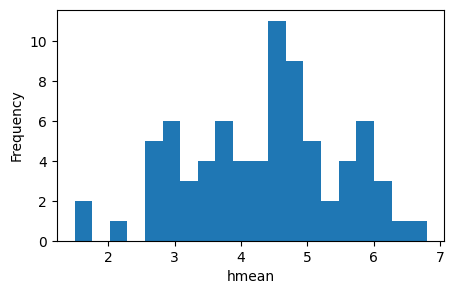

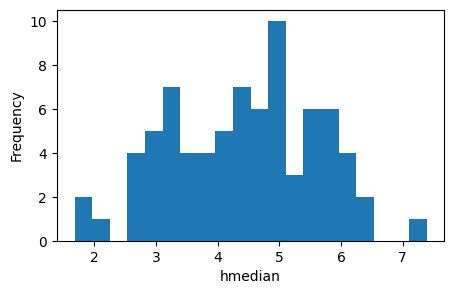

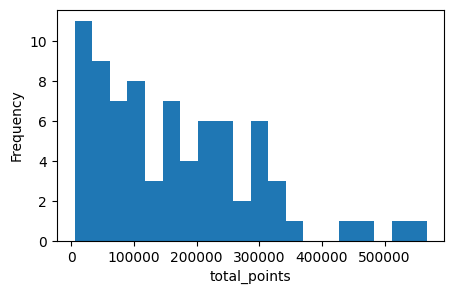

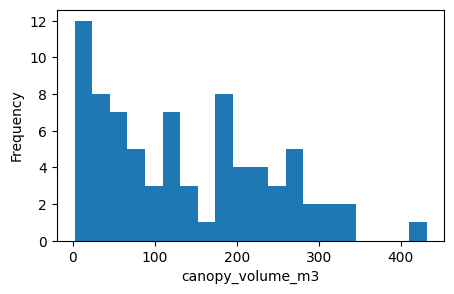

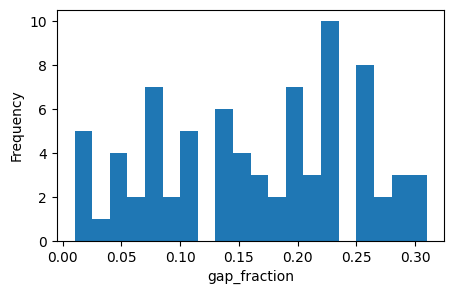

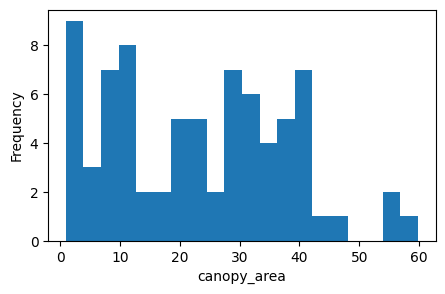

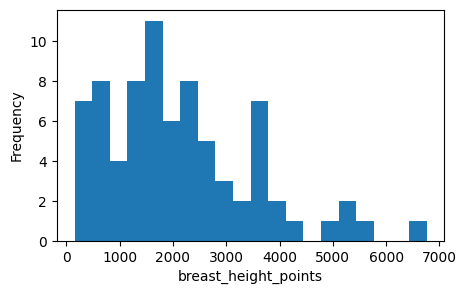

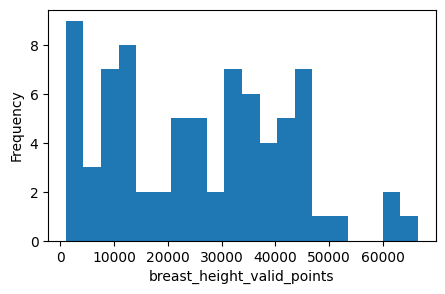

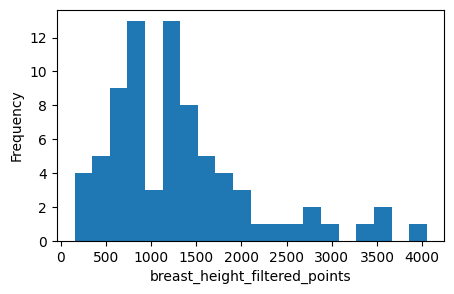

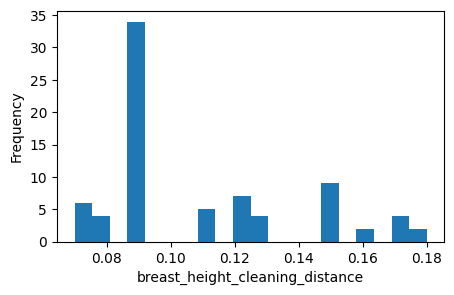

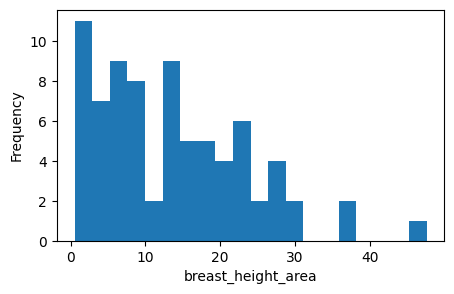

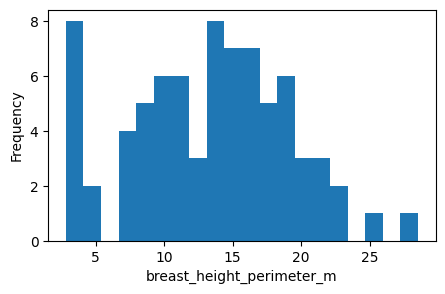

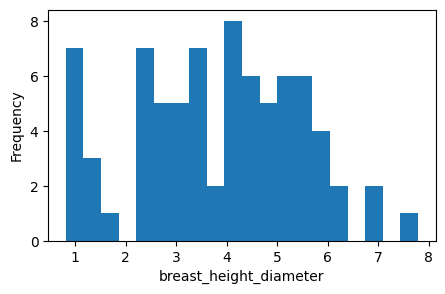

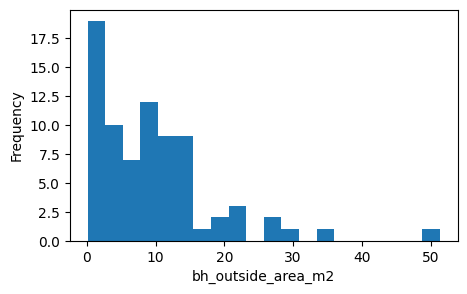

In [85]:
for predictor in predictors:
    plt.figure(figsize=(5,3))
    plt.hist(predictors_gdf[predictor], bins=20)
    plt.xlabel(f'{predictor}')
    plt.ylabel('Frequency')
    plt.show()

#### Is total biomass primarily driven by culm number or culm size?

In [86]:
df = gdf[gdf['total_agb'] != 0].copy()

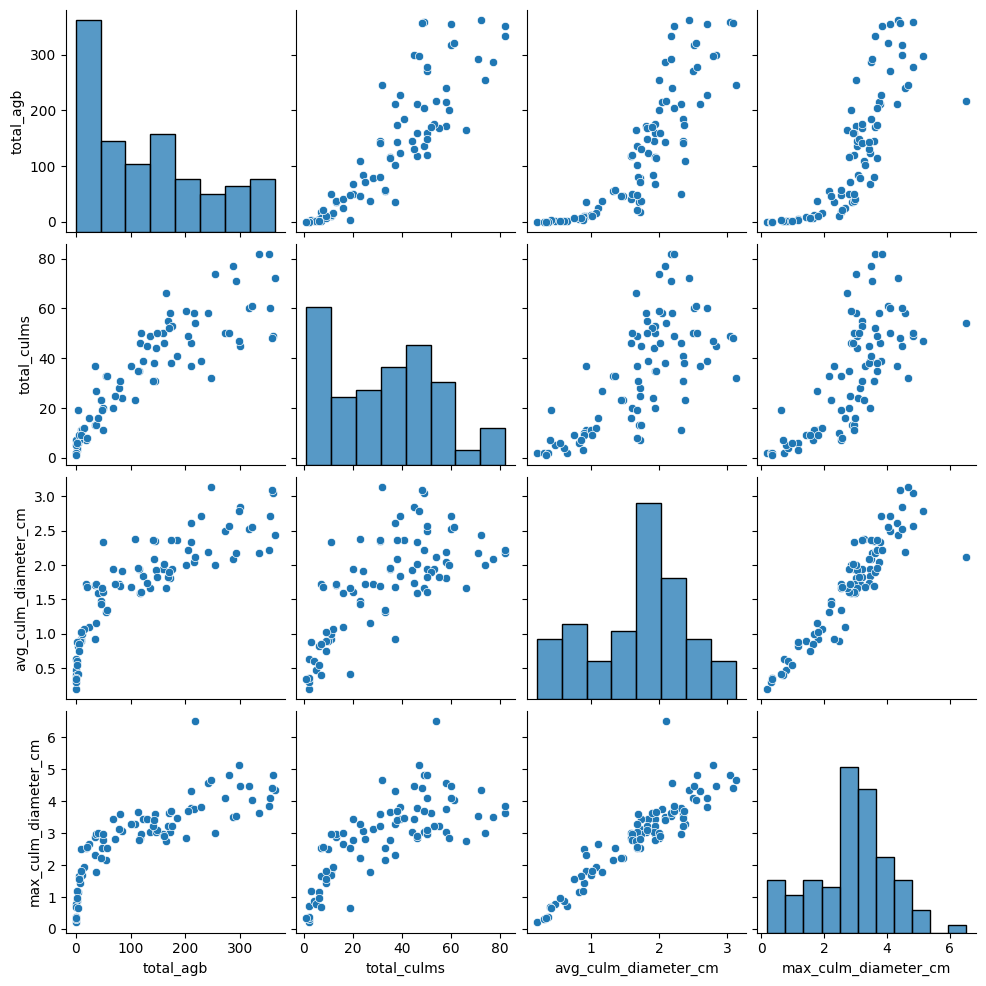

In [87]:
sns.pairplot(
    df[
        [
            "total_agb",
            "total_culms",
            "avg_culm_diameter_cm",
            "max_culm_diameter_cm"
        ]
    ]
)
# plt.savefig(f'{inter_dir}/GRAPHICS/eda_pairplot_total_agb.png', dpi=300)
plt.show()

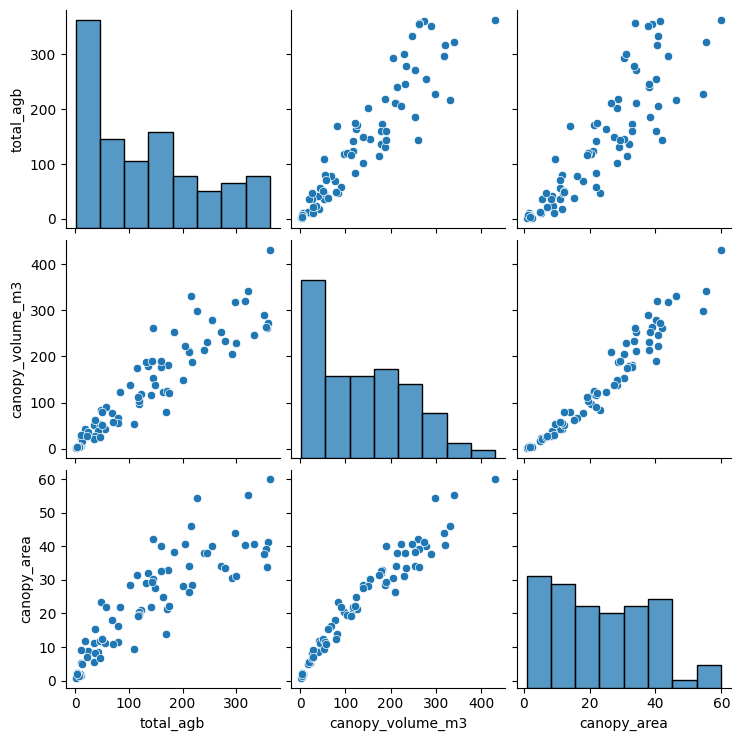

In [88]:
sns.pairplot(
    df[
        [
            "total_agb",
            "canopy_volume_m3",
            "canopy_area"
        ]
    ]
)
# plt.savefig(f'{inter_dir}/GRAPHICS/eda_pairplot_volume.png', dpi=300)
plt.show()

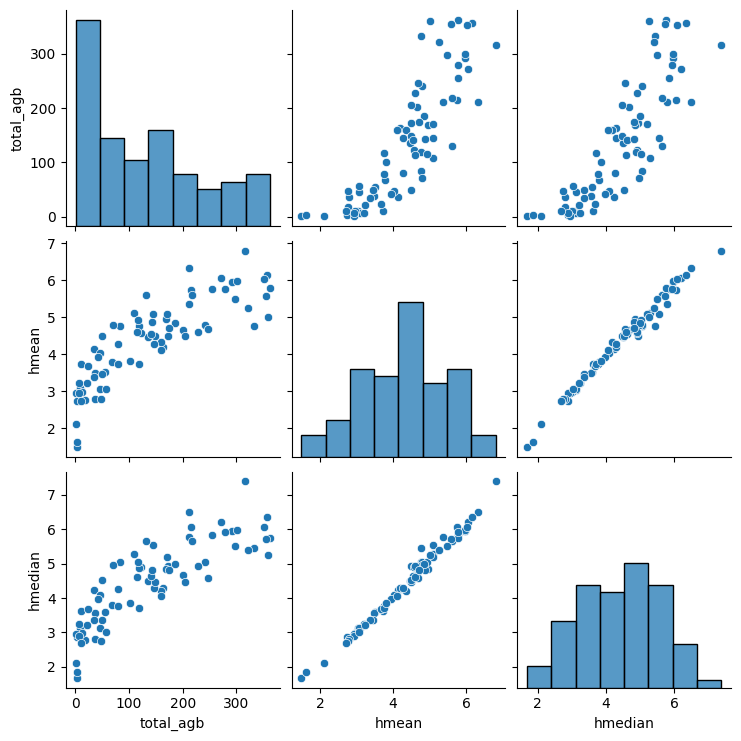

In [89]:
sns.pairplot(
    df[
        [
            "total_agb",
            "hmean",
            "hmedian"
        ]
    ]
)
# plt.savefig(f'{inter_dir}/GRAPHICS/eda_pairplot_height.png', dpi=300)
plt.show()

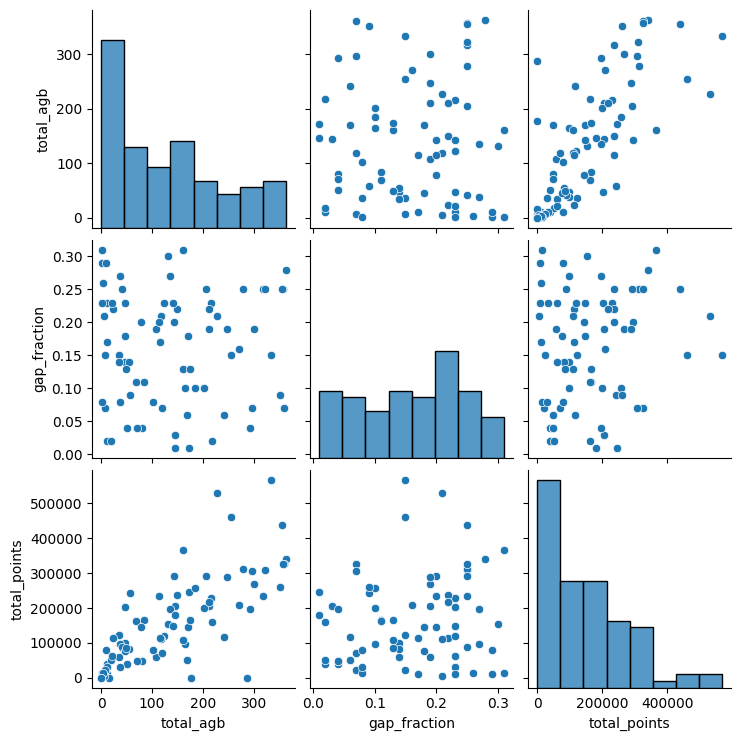

In [90]:
sns.pairplot(
    df[
        [
            "total_agb",
            "gap_fraction",
            'total_points'
        ]
    ]
)
# plt.savefig(f'{inter_dir}/GRAPHICS/eda_pairplot_density.png', dpi=300)
plt.show()

In [91]:
predictors_gdf.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'breast_height_points', 'breast_height_valid_points',
       'breast_height_filtered_points', 'breast_height_cleaning_distance',
       'breast_height_area', 'breast_height_perimeter_m',
       'breast_height_diameter', 'bh_outside_area_m2', 'geometry',
       'adjusted_volume'],
      dtype='str')

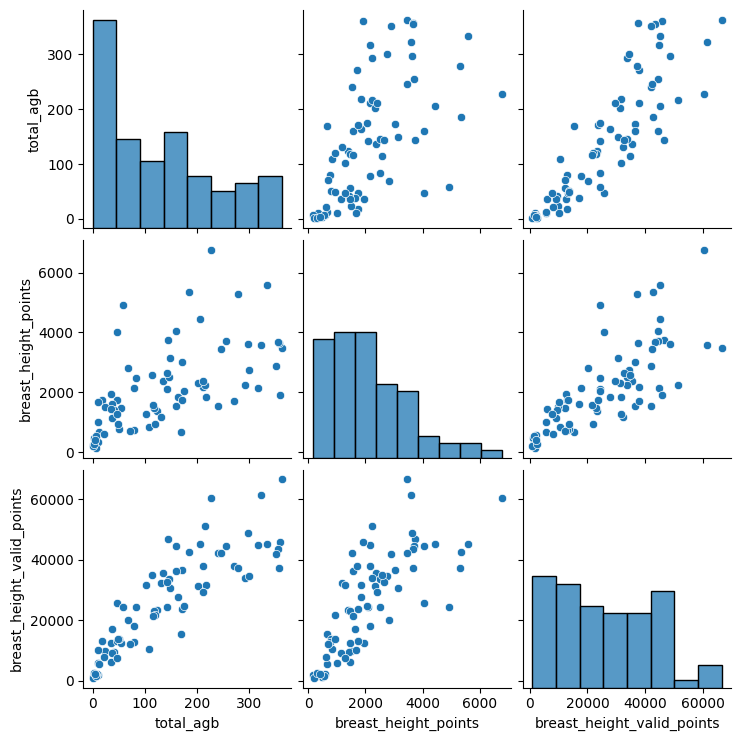

In [92]:
sns.pairplot(
    df[
        [
            "total_agb",
            'breast_height_points', 'breast_height_valid_points'
        ]
    ]
)
plt.show()

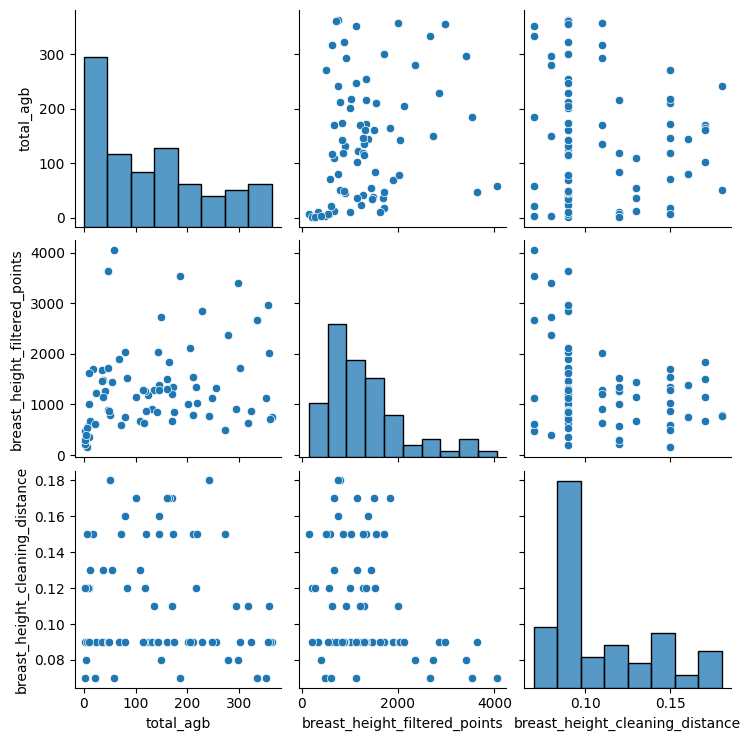

In [93]:
sns.pairplot(
    df[
        [
            "total_agb",
            'breast_height_filtered_points', 'breast_height_cleaning_distance'
        ]
    ]
)
plt.show()

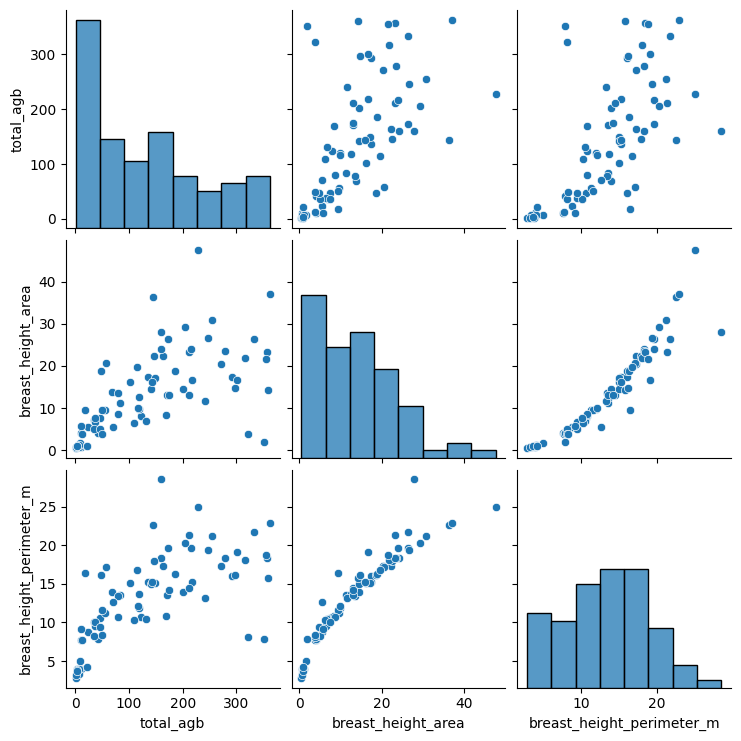

In [94]:
sns.pairplot(
    df[
        [
            "total_agb",
            'breast_height_area', 'breast_height_perimeter_m'
        ]
    ]
)
plt.show()

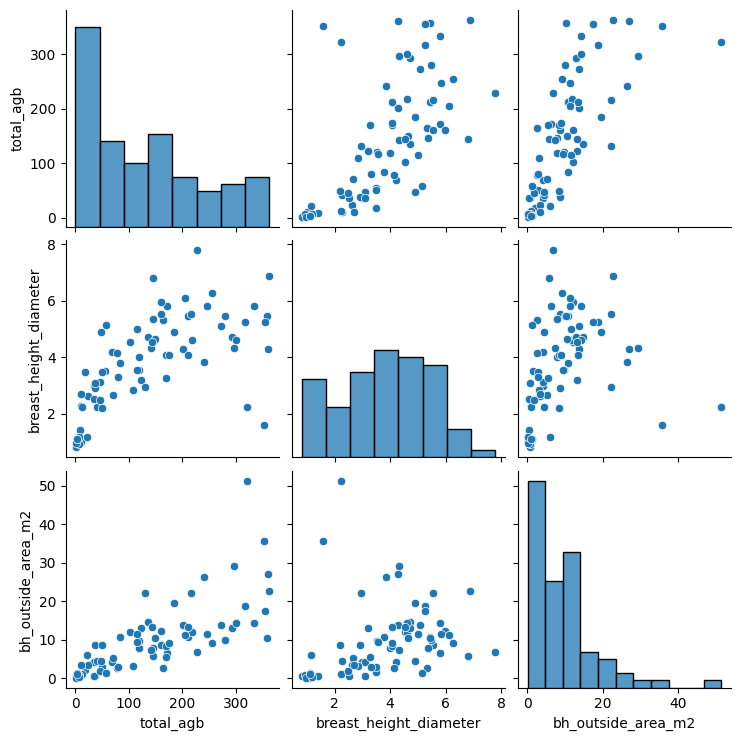

In [95]:
sns.pairplot(
    df[
        [
            "total_agb",
            'breast_height_diameter', 'bh_outside_area_m2'
        ]
    ]
)
plt.show()

#### Findings:
#### Above-Ground Biomass Dynamics

* **Non-Linear Scaling ("Banana" Curve):** 
  The relationship between all structural factors and `total_agb` is positive but distinctly non-linear. This geometric curvature is expected, as biomass scales volumetrically with diameter rather than linearly.
  
* **Culm Count Interactions ("Fan" Shape / Heteroscedasticity):** 
  The relationship between `total_culms` and `total_agb` approaches linearity but exhibits a strong fan-shaped spread (heteroscedasticity) toward the right. 
  * *Interpretation:* High biomass can be achieved by either having many medium size culms or few exceptionally thick culms


#### Culm Density and Diameter Relationships

* **Diminishing Returns (Total Culms vs. Max Culm Diameter):**
  There is a positive, non-linear relationship between the number of culms and the maximum culm diameter, which flattens out at higher densities.
  * *Interpretation:* This highlights a or ceiling effect. Beyond a certain culm density, severe resource competition (light, nutrients, water) prevents individuals from reaching larger maximum diameters, probably due to more shoots coming up and competing.

* **Independence of Average Size (Total Culms vs. Avg Culm Diameter):**
  The scatter plot between `total_culms` and `avg_culm_diameter_cm` displays a highly scattered, near-random distribution.
  * *Interpretation:* Number of culms does not appear to dictate the average diameter of the clump. Average thickness is likely governed by external variables such as clump age, genetic factors, or localized soil conditions rather than overcrowding.


#### Drone Predictor and biomass relationships

* **Most of the predictors show the same heterosdacity as well, showing that there is more variation at higher values of biomass than at lower values**
* **Total number of culms and the diameter of culms drives the amount of biomass, a big contributor into the decision to have breast height parameters to our first DV001, which didnt have any features that could proxy the number and thickness of culms**
* **Gap fraction does not show any relationship with aboveground biomass and so does not help the prediction. This is also true for some of the breast height features eg cleaning distance, filtered points**
* **Breast height valid no of points shows a good linear relationship with biomass, good sign that could aid in modelling**

#### Correlation and feature importances


In [96]:
df[
    [
        "total_agb",
        "total_culms",
        "avg_culm_diameter_cm",
        "max_culm_diameter_cm"
        
    ]
].corr(method="pearson")["total_agb"].sort_values(
    ascending=False
)

total_agb               1.000000
total_culms             0.882194
avg_culm_diameter_cm    0.845773
max_culm_diameter_cm    0.812729
Name: total_agb, dtype: float64

In [97]:
df[
    [
        "total_agb",
        "canopy_volume_m3",
        "canopy_area",
        "hmean",
        "hmedian",
        "gap_fraction",
        'total_points',
        'adjusted_volume'
    ]
].corr(method="pearson")["total_agb"].sort_values(
    ascending=False)

total_agb           1.000000
canopy_volume_m3    0.921195
canopy_area         0.871607
hmedian             0.846094
hmean               0.842718
total_points        0.773670
adjusted_volume     0.714184
gap_fraction        0.010460
Name: total_agb, dtype: float64

In [98]:
df[
    [
        "total_agb",
        "canopy_volume_m3",
        "canopy_area",
        "hmean",
        "hmedian",
        "gap_fraction",
        'total_points',
        'adjusted_volume'
    ]
].corr(method="spearman")["total_agb"].sort_values(
    ascending=False)

total_agb           1.000000
canopy_volume_m3    0.949314
canopy_area         0.909155
hmean               0.879601
hmedian             0.878862
total_points        0.811894
adjusted_volume     0.774620
gap_fraction       -0.040353
Name: total_agb, dtype: float64

In [99]:
df.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'breast_height_points', 'breast_height_valid_points',
       'breast_height_filtered_points', 'breast_height_cleaning_distance',
       'breast_height_area', 'breast_height_perimeter_m',
       'breast_height_diameter', 'bh_outside_area_m2', 'geometry',
       'adjusted_volume'],
      dtype='str')

In [100]:
df[
    [
        "total_agb",
        'breast_height_points', 'breast_height_valid_points',
        'breast_height_filtered_points', 'breast_height_cleaning_distance',
        'breast_height_area', 'breast_height_perimeter_m',
        'breast_height_diameter', 'bh_outside_area_m2'
    ]
].corr(method="pearson")["total_agb"].sort_values(
    ascending=False)

total_agb                          1.000000
breast_height_valid_points         0.871641
bh_outside_area_m2                 0.754945
breast_height_perimeter_m          0.662071
breast_height_diameter             0.647703
breast_height_area                 0.621370
breast_height_points               0.606147
breast_height_filtered_points      0.248079
breast_height_cleaning_distance   -0.083473
Name: total_agb, dtype: float64

In [101]:
df[
    [
        "total_agb",
        'breast_height_points', 'breast_height_valid_points',
        'breast_height_filtered_points', 'breast_height_cleaning_distance',
        'breast_height_area', 'breast_height_perimeter_m',
        'breast_height_diameter', 'bh_outside_area_m2'
    ]
].corr(method="spearman")["total_agb"].sort_values(
    ascending=False)

total_agb                          1.000000
breast_height_valid_points         0.908959
bh_outside_area_m2                 0.843478
breast_height_perimeter_m          0.751080
breast_height_area                 0.736053
breast_height_diameter             0.735867
breast_height_points               0.714706
breast_height_filtered_points      0.321783
breast_height_cleaning_distance   -0.053105
Name: total_agb, dtype: float64

In [102]:
selected_cols = [
    "canopy_volume_m3",
    "canopy_area",
    "hmean",
    "hmedian",
    "total_points",
    'breast_height_valid_points',
    'bh_outside_area_m2',
    'breast_height_perimeter_m',
    "total_agb"
]

In [103]:
results = []

for feature in selected_cols:

    x = df[feature]
    y = df["total_agb"]

    mask = x.notna() & y.notna()

    pearson_r, pearson_p = pearsonr(
        x[mask],
        y[mask]
    )

    spearman_r, spearman_p = spearmanr(
        x[mask],
        y[mask]
    )

    results.append({
        "feature": feature,
        "pearson_r": pearson_r,
        "spearman_r": spearman_r,
        "pearson_p": pearson_p,
        "spearman_p": spearman_p
    })

corr_df = pd.DataFrame(results)

corr_df.sort_values(
    "spearman_r",
    key=lambda x: abs(x),
    ascending=False
)

,feature,pearson_r,spearman_r,pearson_p,spearman_p
8,total_agb,1.000000,1.000000,0.000000e+00,0.000000e+00
0,canopy_volume_m3,0.921195,0.949314,1.787518e-32,1.944701e-39
1,canopy_area,0.871607,0.909155,6.298675e-25,2.957374e-30
5,breast_height_valid_points,0.871641,0.908959,6.239639e-25,3.194632e-30
2,hmean,0.842718,0.879601,7.330485e-22,6.574668e-26
3,hmedian,0.846094,0.878862,3.467131e-22,8.155416e-26
6,bh_outside_area_m2,0.754945,0.843478,2.178376e-15,6.203588e-22
4,total_points,0.773670,0.811894,1.576688e-18,1.434366e-21
7,breast_height_perimeter_m,0.662071,0.751080,5.500815e-11,3.624617e-15


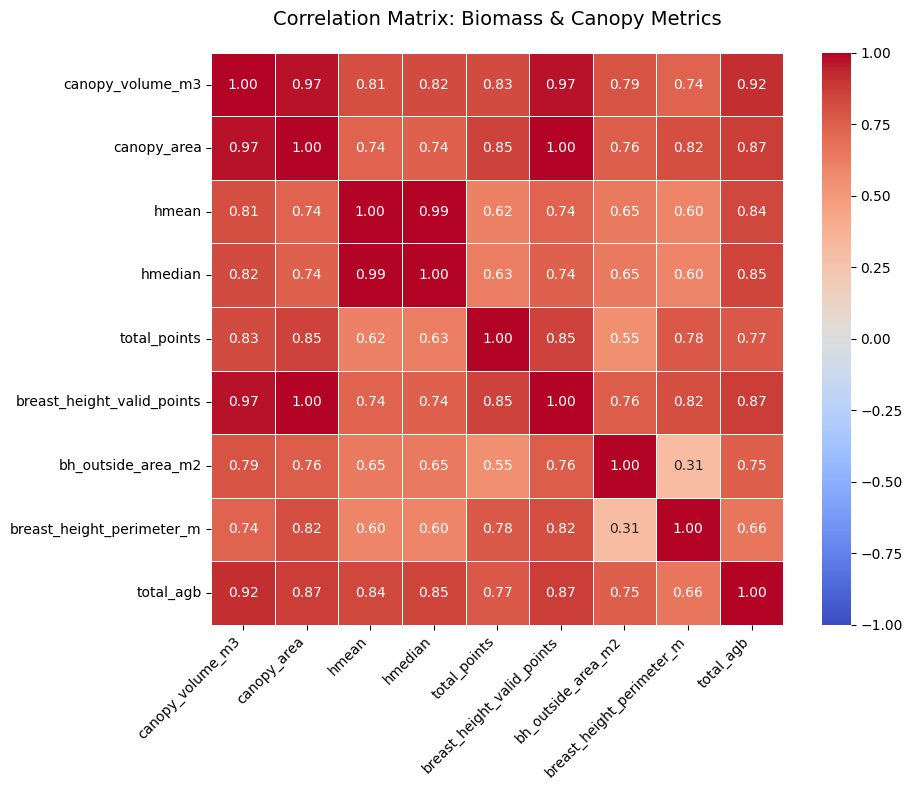

In [104]:
corr_matrix = df[selected_cols].corr(method="pearson")

# plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,  # Displays correlation coefficients
    cmap="coolwarm",  # Diverging color palette (blue = negative, red = positive)
    fmt=".2f",  # Rounds to 2 decimal places
    vmin=-1,
    vmax=1,  # Standardizes the color bar limits
    square=True,  
    linewidths=0.5,  # Adds lines between the cells for readability
)

plt.title("Correlation Matrix: Biomass & Canopy Metrics", fontsize=14, pad=20)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# plt.savefig(f'{inter_dir}/GRAPHICS/eda_corr_matrix.png', dpi=300)
plt.show()

/tmp/ipykernel_3760/3690868821.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agb_corr.values, y=agb_corr.index, palette="viridis")


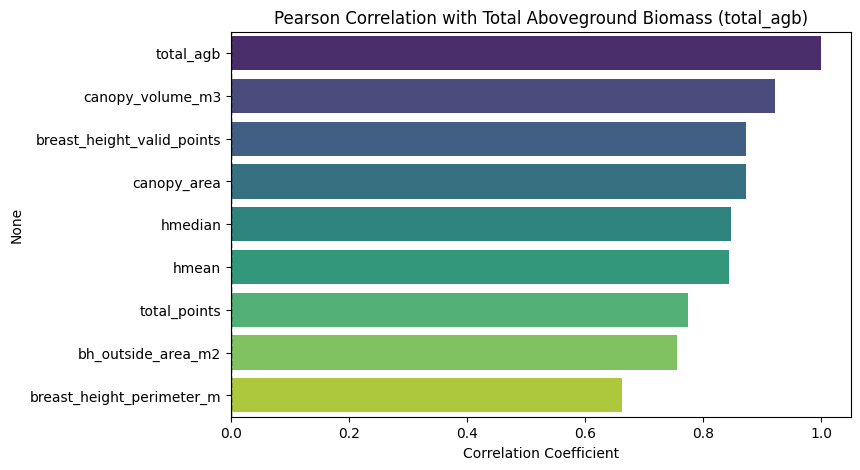

In [105]:
# Calculate correlation series against total_agb and sort
agb_corr = df[selected_cols].corr(method="pearson")["total_agb"].sort_values(ascending=False)

# Plot as a sorted bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=agb_corr.values, y=agb_corr.index, palette="viridis")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Pearson Correlation with Total Aboveground Biomass (total_agb)")
plt.xlabel("Correlation Coefficient")
plt.show()


## 6. Relationships Among Predictors

Correlations among predictor variables were examined to identify
redundancy and potential multicollinearity.

This is important because canopy area, canopy volume and height describe
related aspects of clump structure.

In [106]:
cols = [
    "canopy_area",
    "hmean",
    "canopy_volume_m3",
    'breast_height_valid_points',
    'total_points',
    'bh_outside_area_m2',
    'breast_height_perimeter_m'
]

df[cols].corr()

,canopy_area,hmean,canopy_volume_m3,breast_height_valid_points,total_points,bh_outside_area_m2,breast_height_perimeter_m
canopy_area,1.000000,0.737941,0.971124,0.999999,0.853594,0.759109,0.816064
hmean,0.737941,1.000000,0.814778,0.737967,0.615443,0.648245,0.595274
canopy_volume_m3,0.971124,0.814778,1.000000,0.971158,0.827869,0.789988,0.741732
breast_height_valid_points,0.999999,0.737967,0.971158,1.000000,0.853550,0.759216,0.815887
total_points,0.853594,0.615443,0.827869,0.853550,1.000000,0.549952,0.779715
bh_outside_area_m2,0.759109,0.648245,0.789988,0.759216,0.549952,1.000000,0.311687
breast_height_perimeter_m,0.816064,0.595274,0.741732,0.815887,0.779715,0.311687,1.000000


## 7. Investigating possibility for site effect


In [107]:
df.groupby("psp")["total_agb"].describe()

,count,mean,std,min,25%,50%,75%,max
psp,,,,,,,,
1a-APM-01,15.0,58.412000,66.943427,0.10,10.4800,35.490,76.0900,211.12
1a-APM-02,14.0,73.011429,66.854333,1.31,9.1725,59.935,121.7750,215.70
1a-APM-07,13.0,123.534615,86.206089,5.94,49.9800,119.430,169.1600,286.94
1a-APM-08,14.0,109.679286,107.076948,0.21,4.4000,93.435,193.5700,292.78
1a-APM-13,5.0,75.784000,87.745381,0.30,46.0700,47.430,57.4300,227.69
1a-GB-03,12.0,213.554167,123.408311,0.13,147.1200,233.075,318.2075,362.77
1a-GB-05,14.0,224.202143,115.496522,21.01,151.0325,225.700,338.4375,359.82


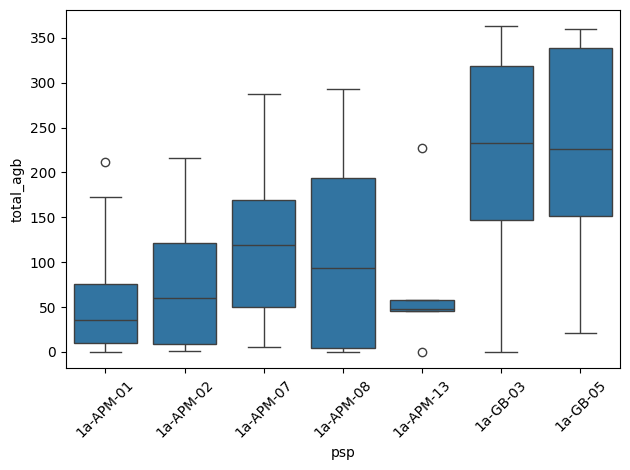

In [108]:
sns.boxplot(
    data=df,
    x="psp",
    y="total_agb"
)

plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig(f'{inter_dir}/GRAPHICS/eda_biomass_site_effect.png', dpi=300)
plt.show()

### Findings:
* **Strong Site Effect (GB vs. APM):** There is a distinct difference between sites. The `1a-GB` sites are highly productive, yielding mean biomass values ($>200$) that are 2x to 3x higher than `1a-APM` sites. 
* **High Internal Variance:** The standard deviations (`std`) are remarkably high at every single site. This shows that while a site dictates the *average environmental capacity* (e.g., better soil or moisture at GB sites), individual clump structural traits still drive huge internal diversity.

#### More importantly: does the drone-biomass relationship change by PSP?

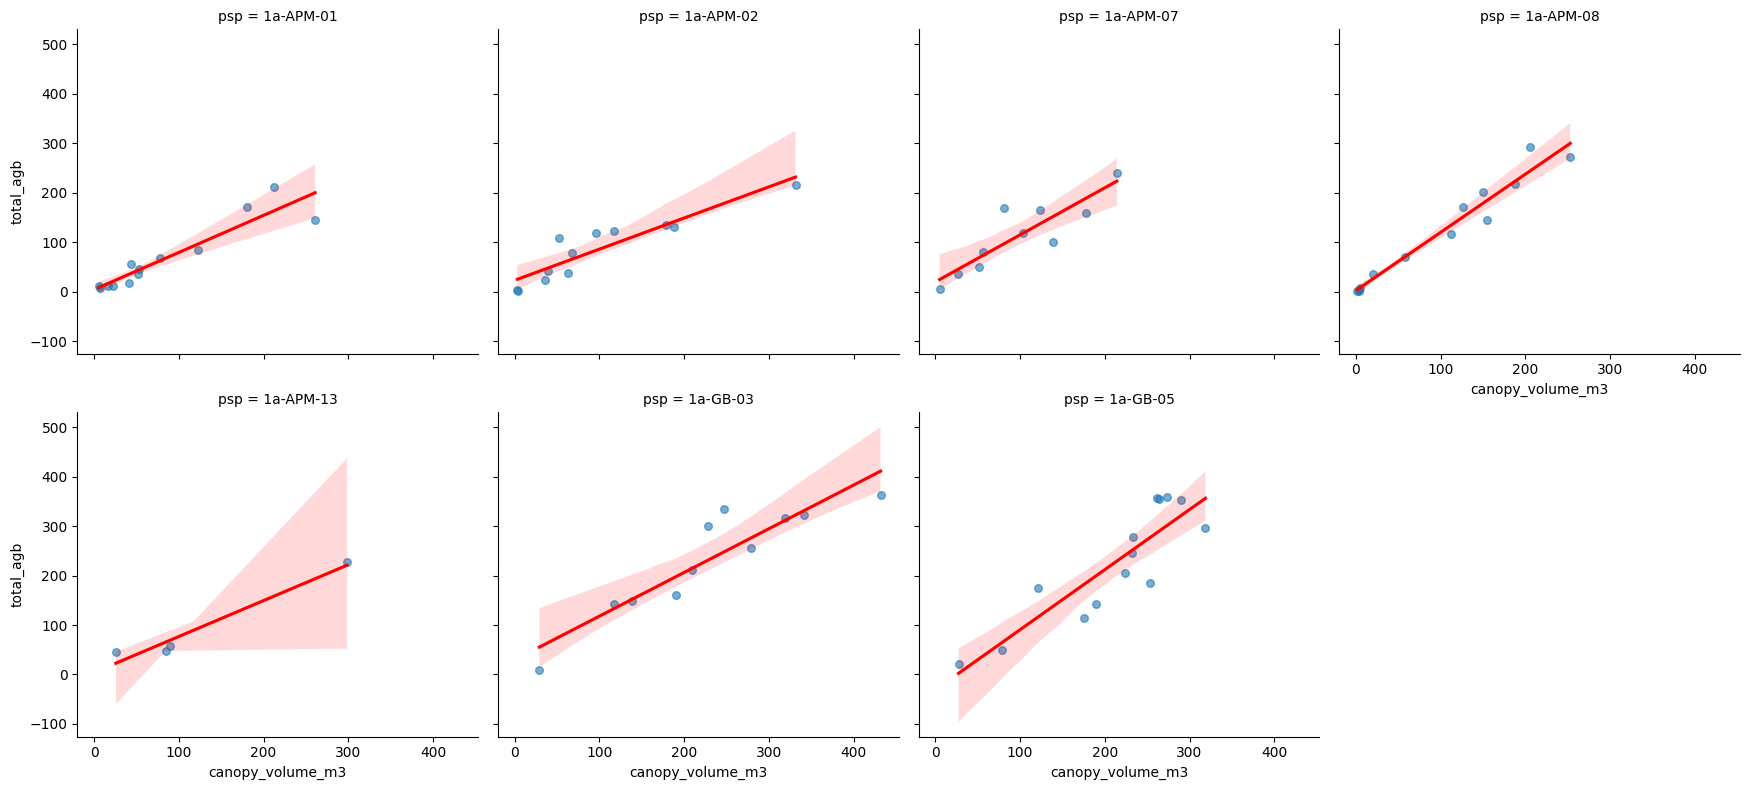

In [109]:
g = sns.lmplot(
    data=df,
    x="canopy_volume_m3",  
    y="total_agb",
    col="psp",        # Creates a separate subplot for each site
    col_wrap=4,       # Wraps the subplots into a clean 3-column grid
    height=4,
    aspect=1.1,
    scatter_kws={"alpha": 0.6, "s": 30},  # Makes dots slightly transparent and smaller
    line_kws={"color": "red"}             # Keeps regression lines bold and easy to read
)

# Adjust spacing so titles don't overlap
plt.tight_layout()
# plt.savefig(f'{inter_dir}/GRAPHICS/eda_canopy_volume_agb_per_psp.png', dpi = 300)
plt.show()

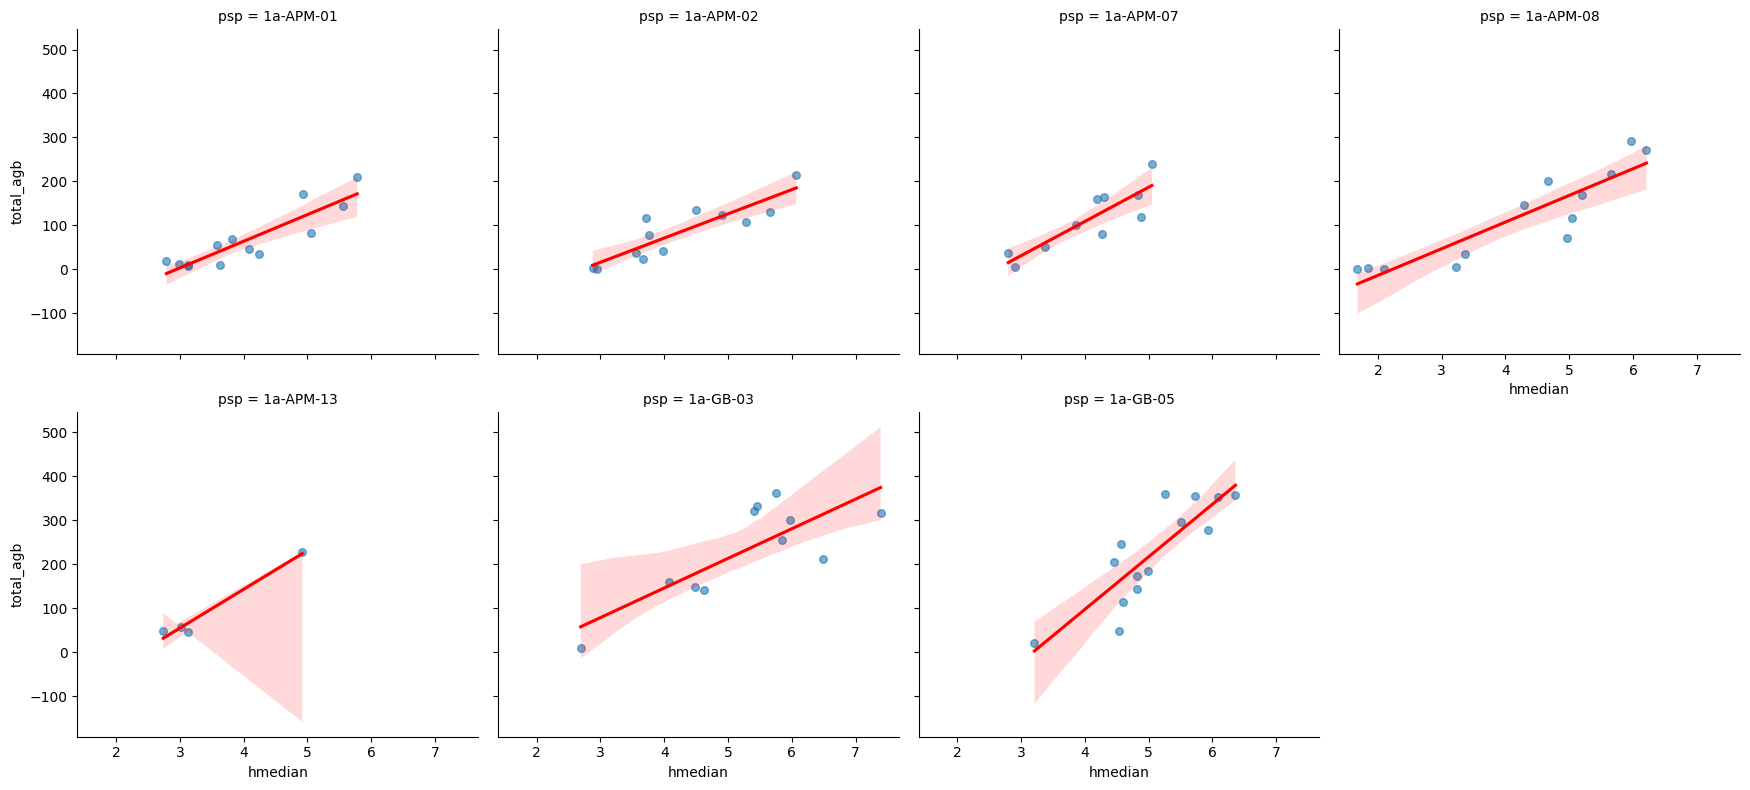

In [110]:
g = sns.lmplot(
    data=df,
    x="hmedian",  
    y="total_agb",
    col="psp",        # Creates a separate subplot for each site
    col_wrap=4,       # Wraps the subplots into a clean 3-column grid
    height=4,
    aspect=1.1,
    scatter_kws={"alpha": 0.6, "s": 30},  # Makes dots slightly transparent and smaller
    line_kws={"color": "red"}             # Keeps regression lines bold and easy to read
)

# Adjust spacing so titles don't overlap
plt.tight_layout()
plt.show()

In [111]:
# Define the non-redundant, high-value factors 
factors = ['total_agb', 'total_culms', 'canopy_area', 'hmean', 'canopy_volume_m3', 'avg_culm_diameter_cm', 'hmedian']

# Create an empty list to store our structured site correlation data
site_corrs = []

# Loop through each unique plot and grab its specific correlation values
for psp, group in df.groupby('psp'):
    # Run correlation only if there are enough points to calculate a meaningful relationship
    if len(group) > 3:
        corr_matrix = group[factors].corr()
        
        # Pull out the specific correlations of interest relative to Above-Ground Biomass
        site_corrs.append({
            'PSP Site': psp,
            'Sample Size (N)': len(group),
            'AGB vs. Culms': corr_matrix.loc['total_agb', 'total_culms'],
            'AGB vs. Canopy Area': corr_matrix.loc['total_agb', 'canopy_area'],
            'AGB vs. Height (hmean)': corr_matrix.loc['total_agb', 'hmean'],
            'Culms vs. Area': corr_matrix.loc['total_culms', 'canopy_area'],
            'AGB vs. Canopy Volume': corr_matrix.loc['total_agb', 'canopy_volume_m3'],
            'AGB vs. Culm Diameter': corr_matrix.loc['total_agb', 'avg_culm_diameter_cm']
        })

# Combine into a clean summary DataFrame
df_site_summary = pd.DataFrame(site_corrs).round(3)

# Display the summary table sorted by the strength of the Canopy Area relationship
display(df_site_summary.sort_values(by='AGB vs. Canopy Area', ascending=False))


,PSP Site,Sample Size (N),AGB vs. Culms,AGB vs. Canopy Area,AGB vs. Height (hmean),Culms vs. Area,AGB vs. Canopy Volume,AGB vs. Culm Diameter
3,1a-APM-08,14,0.928,0.955,0.898,0.893,0.977,0.925
4,1a-APM-13,5,0.789,0.938,0.989,0.752,0.977,0.915
0,1a-APM-01,15,0.916,0.928,0.861,0.785,0.930,0.798
1,1a-APM-02,14,0.962,0.925,0.872,0.932,0.917,0.795
5,1a-GB-03,12,0.894,0.842,0.762,0.818,0.918,0.828
2,1a-APM-07,13,0.946,0.839,0.847,0.739,0.880,0.897
6,1a-GB-05,14,0.840,0.792,0.840,0.757,0.880,0.741


## 8. Are the largest clumps fundamentally different?

In [112]:
df["biomass_group"] = pd.qcut(
    df["total_agb"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ]
)

In [113]:
df.groupby("biomass_group")[
    [
        "total_agb",
        "canopy_area",
        "canopy_volume_m3",
        "hmean",
        "total_culms",
        "avg_culm_diameter_cm"
    ]
].median()

,total_agb,canopy_area,canopy_volume_m3,hmean,total_culms,avg_culm_diameter_cm
biomass_group,,,,,,
Low,4.01,1.995,5.37,2.940,7.0,0.785
Medium-Low,52.59,12.130,56.76,3.800,23.5,1.685
Medium-High,159.91,28.645,152.14,4.555,49.0,1.920
High,289.86,38.100,262.07,5.740,56.0,2.510


#### Findings:

* **Allometric Scaling Strategy:**
  High-biomass clumps are fundamentally different because they execute a multi-dimensional growth strategy. To reach the "High" tier, clumps simultaneously maximize ground metrics (count and diameter) and canopy metrics (area and height). 
  
* **Vertical Saturation vs. Horizontal Expansion:**
  Between the top two tiers (Medium-High to High), height growth slows down drastically ($+1.0\text{m}$), whereas canopy area continues to widen aggresively. This indicates that biomass accumulation in mature clumps shifts from vertical competition for light to horizontal territory expansion.

* **Ground-Level:**
  The most dramatic transformation occurs at ground level. High-biomass clumps support $8\times$ more culms than low-biomass ones, and those culms are $3\times$ thicker on average. Because weight scales with the square of the diameter ($\text{Area} \propto d^2$), the concurrent increase in both culm thickness and culm count explains the geometric explosion in `total_agb`.

#### Is biomass density more predictable than total biomass?

In [114]:
df["agb_per_area"] = (
    df["total_agb"] /
    df["canopy_area"]
)

df["agb_per_volume"] = (
    df["total_agb"] /
    df["canopy_volume_m3"]
)

In [115]:
targets = ["avg_culm_diameter_cm", "total_culms"]
features = ['canopy_area', 'canopy_volume_m3', 'hmean']

for target in targets:
    #Include the target in the slice
    sliced_df = df[features + [target]]
    
    # Compute correlation and extract just the target's column
    correlation_series = sliced_df.corr()[target]
    
    # Print the features relative to that target (excluding the target correlating with itself)
    print(f"\nCorrelation for {target}:")
    print(correlation_series[features])


Correlation for avg_culm_diameter_cm:
canopy_area         0.802291
canopy_volume_m3    0.811210
hmean               0.831331
Name: avg_culm_diameter_cm, dtype: float64

Correlation for total_culms:
canopy_area         0.796328
canopy_volume_m3    0.799406
hmean               0.746592
Name: total_culms, dtype: float64


#### Findings:
* **The Cancellation Trap:**  Since absolute size is the primary driver of total mass, density metrics erase the most valuable predictive signals in the dataset.
* **Density Flattening:** Biomass density can be identical for an extremely small clump and a massive, mature clump. Because remote sensing features measure the *outer structural boundary*, they cannot differentiate density variations independent of scale.
* **Final Modeling Strategy:** The absolute metric `total_agb` must remain the target variable for all predictive pipelines. The canopy size metrics retain strong linear and non-linear relationships with total mass that will be highly effective in a machine learning framework.

#### Testing for spatial autocorrelation

In [116]:
spatial_df = df.copy()

spatial_df = spatial_df[
    spatial_df.geometry.notna()
].copy()

spatial_df = spatial_df[
    ~spatial_df.geometry.is_empty
].copy()

print(f"Observations: {len(spatial_df)}")
print(f"CRS: {spatial_df.crs}")

Observations: 87
CRS: EPSG:32735


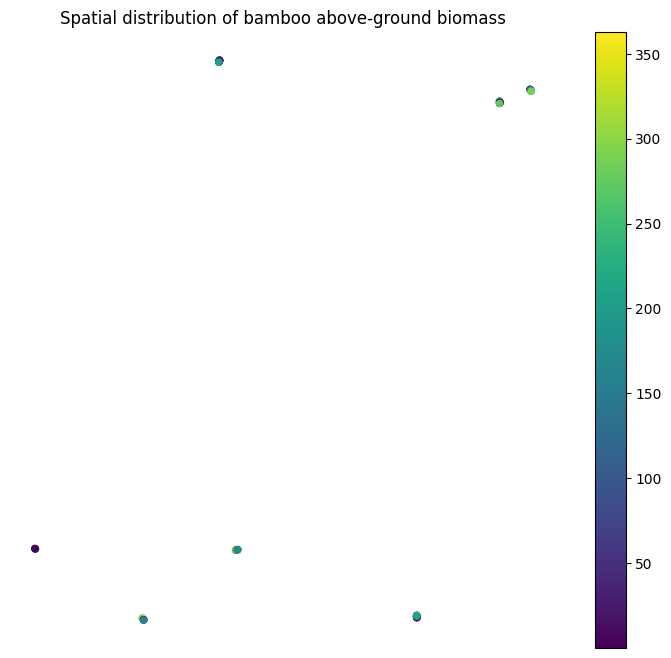

In [117]:
fig, ax = plt.subplots(figsize=(10, 8))

spatial_df.plot(
    column="total_agb",
    ax=ax,
    legend=True,
    markersize=20
)

ax.set_title("Spatial distribution of bamboo above-ground biomass")
ax.set_axis_off()

plt.show()

In [ ]:
psp_results = []

for psp, group in spatial_df.groupby("psp"):

    group = group.dropna(
        subset=["total_agb", "geometry"]
    ).copy()

    # Need enough observations to construct meaningful neighbours
    if len(group) < 6:
        continue

    coords = np.column_stack([
        group.geometry.centroid.x,
        group.geometry.centroid.y
    ])

    k = min(4, len(group) - 1)

    weights = KNN.from_array(
        coords,
        k=k
    )

    weights.transform = "R"

    moran = Moran(
        group["total_agb"].to_numpy(),
        weights
    )

    psp_results.append({
        "psp": psp,
        "n": len(group),
        "moran_I": moran.I,
        "expected_I": moran.EI,
        "p_value": moran.p_sim,
        "significant": moran.p_sim < 0.05
    })

psp_moran = pd.DataFrame(psp_results)

psp_moran

/home/gacho/projects/acre_insights/ecoplanet_bamboo/04_SCRIPTS/venv/lib/python3.12/site-packages/esda/moran.py:192: RuntimeWarning: divide by zero encountered in scalar divide
  self.z_norm = (self.I - self.EI) / self.seI_norm
/home/gacho/projects/acre_insights/ecoplanet_bamboo/04_SCRIPTS/venv/lib/python3.12/site-packages/esda/moran.py:193: RuntimeWarning: divide by zero encountered in scalar divide
  self.z_rand = (self.I - self.EI) / self.seI_rand


,psp,n,moran_I,expected_I,p_value,significant
0,1a-APM-01,15,-0.026384,-0.071429,0.322,False
1,1a-APM-02,14,0.557697,-0.076923,0.001,True
2,1a-APM-07,13,-0.048192,-0.083333,0.332,False
3,1a-APM-08,14,0.267426,-0.076923,0.033,True
4,1a-APM-13,5,-0.250000,-0.250000,0.399,False
5,1a-GB-03,12,0.285863,-0.090909,0.032,True
6,1a-GB-05,14,-0.129652,-0.076923,0.435,False


Interpretation:

* Moran's I > 0: nearby observations tend to have similar biomass.
* Moran's I ≈ 0: little evidence of global spatial autocorrelation.
* Moran's I < 0: nearby observations tend to be dissimilar.
* p_sim < 0.05: evidence against the null hypothesis of spatial randomness under the permutation test.

## 9. Core Inferences and way forward:

* **Canopy Saturation in High-Biomass Sites (`1a-GB-05`):**
  We observe a major structural breakdown in the `1a-GB-05` plot. The correlation between `total_agb` and `canopy_area` drops (compared to $>0.90$ in early APM sites). 
  * *Ecological Inference:* In highly productive or mature sites, the canopy layer reaches a closed state (saturation). Once the canopy completely covers the plot area, the pace of canopy area and biomass increase starts to slow. Canopy area starts increasing slowly as the clump builds mass underneath.

* **Modeling Action Plan:**
  Because the predictive power of parameters changes so drastically based on the location, we have this clear path forward:
  1. **Group fold validation:** The idea is to build a model thats transferrable to any other site to avoid overfitting to one site. This means that well need a good train test split that does not have same psp plants appearing in both train and test, which could falsely inflate accuracies.
  2. `canopy_volume_m3` has a strong positive relationship with biomass.
  3. Canopy area and mean height also provide useful information.
  4. Somw canopy predictors are strongly related to one another, indicating redundancy between measures of canopy size.
  5. Biomass is right-skewed and contains a small number of high-value observations.
  6. Breast-height structural variables provide additional information, although their contribution is relatively modest.
  7. The observed relationships support testing both linear and nonlinear model forms.

* **These findings informed the model structures evaluated in the modelling stage.**
